In [1]:
from InterOptimus.itworker import InterfaceWorker
from pymatgen.core.structure import Structure
from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

/opt/anaconda3/envs/3.12/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# Define InterfaceWorker

In [2]:
film_conv = Structure.from_file('film.cif')
substrate_conv = Structure.from_file('substrate.cif')
iw = InterfaceWorker(film_conv, substrate_conv)

/Users/jason/Downloads/pymatgen-master/src/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


# lattice matching

In [3]:
iw.lattice_matching(max_area = 20, max_length_tol = 0.03, max_angle_tol = 0.03,
                    film_max_miller = 1, substrate_max_miller = 1, film_millers = None, substrate_millers = None)
#Note max millers are in primitive cell, should be different from the indices in the polar projection below which are in conventional cell
#If you specify miller indices yourself, just ignore film_max_miller and substrate_max_miller

2


checking matching identity:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/jason/Documents/GitHub/InterOptimus/InterOptimus/matching.py:966: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


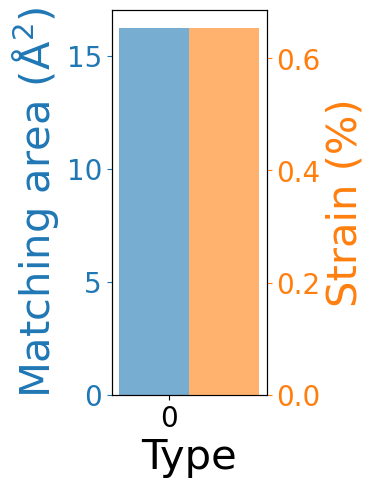

In [4]:
#Visualize matching information
iw.ems.plot_unique_matches()

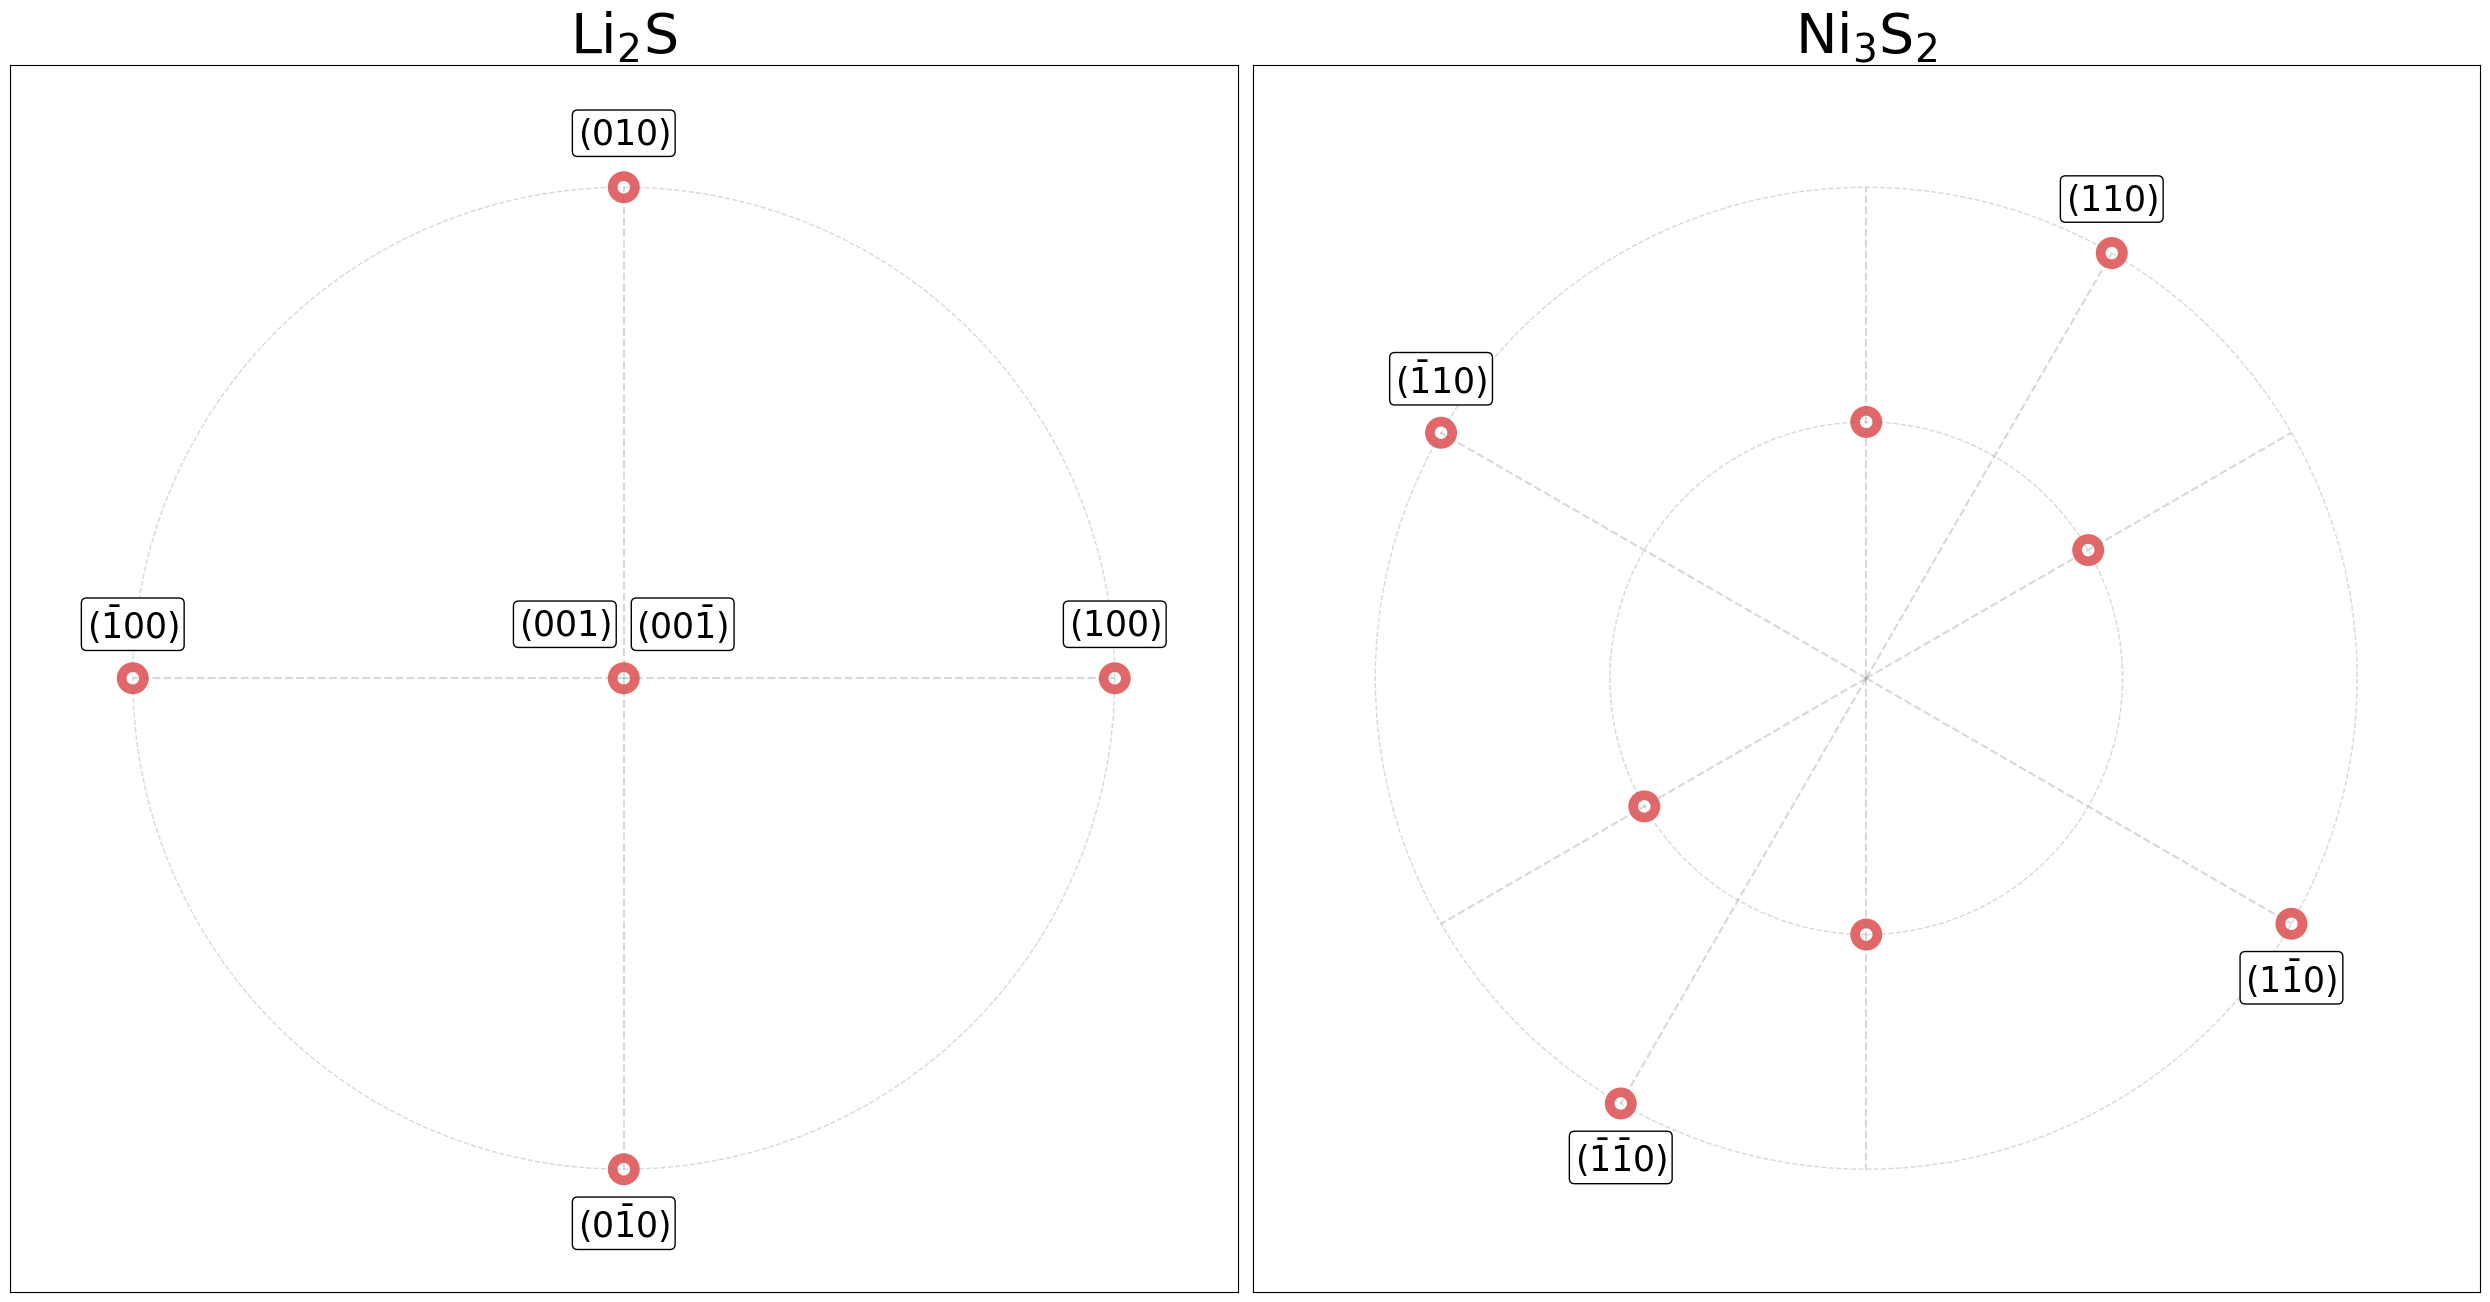

In [5]:
iw.ems.plot_matching_data(['Li$_2$S', 'Ni$_3$S$_2$'],'Ni3S2_Li2S_more.jpg', show_millers = True, show_legend = True)

# Define interface structural parameters 

For usage presentation, a large **termination_ftol** value is applied there.  
However, for some complex systems, a small enough **termination_ftol** (e.g. 0.01) is necessary to find stable interface structures.

In [6]:
#double_interface set to True to exclude vaccum
iw.parse_interface_structure_params(termination_ftol = 0.2, film_thickness = 15, \
                                    substrate_thickness = 15, double_interface= True)



match 0: thicknesses (film, substrate) (2.84, 4.03) (5, 4) (14.18 16.12)
symmetry checking progress: 100%:  ▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋▋
match 0: number of unique terminations: 6


# Baysian Optimization by MLIP for Rigid Body Translation (RBT)

In [7]:
#define structure optimization conditions (optional). If not called, the non-optimized energy and structure will be used
iw.parse_optimization_params(fmax = 0.05, 
                             steps = 200, 
                             device = 'cpu', 
                             discut = 0.8, 
                             ckpt_path = 'orb-v3-conservative-inf-omat-20250404.ckpt')

**fmax**: tolerance to stop structure optimization  
**steps**: maximum relaxing steps  
**device**: device to use for MLIP  
**ckpt_path**: path to store the check point, downloading if not set  
**discut**: those with atoyms closer than discut will have energy as 0 (ignore these structures)  

In [8]:
iw.global_minimization(n_calls_density = 1, 
                       z_range = (0.5, 3),
                       calc = 'orb-models', 
                       strain_E_correction = True)

Initializing ORB calculator on device: cpu


/opt/anaconda3/envs/3.12/lib/python3.12/site-packages/orb_models/utils.py:30: UserWarning: Setting global torch default dtype to torch.float32.
  warnings.warn(f"Setting global torch default dtype to {torch_dtype}.")


ORB initialization success


matches:   0%|          | 0/1 [00:00<?, ?it/s]

unique terminations:   0%|          | 0/6 [00:00<?, ?it/s]

...

num of selected low-energy its: 1


registration optimizing:   0%|          | 0/16 [00:00<?, ?it/s]

num of selected low-energy its: 1


registration optimizing:   0%|          | 0/16 [00:00<?, ?it/s]

num of selected low-energy its: 1
[np.float64(1.413334711376048), np.float64(2.0025019322603947), np.float64(1.4283051873845753), np.float64(1.198782964761372), np.float64(2.05551547217602), np.float64(1.8631711854493704)]


**n_calls**: number of bayesian optimization for each RBT optimizatio  
**z_range**: range of z coordinates for RBT optimization  
**calc**: energy calculator (only for orb-models and sevenn)  
**strain_E_correction**: whether the binding energy or interface energy is corrected considering film elastic energy by strain

In [9]:
iw.global_optimized_data

,$h_f$,$k_f$,$l_f$,$h_s$,$k_s$,$l_s$,$A$ (Å$^2$),$\epsilon$,$E_{it}$ $(J/m^2)$,$E_{el}$ $(eV/atom)$,...,$w_{f2}$,$u_{s1}$,$v_{s1}$,$w_{s1}$,$u_{s2}$,$v_{s2}$,$w_{s2}$,$T$,$i_m$,$i_t$
4,-1,0,0,1,0,1,16.248674,0.00654,0.466741,-0.001591,...,1/2,-1/3,1/3,1/3,-1/3,-2/3,1/3,"(2_Li_P4/mmm_2, 2_NiS_Pmm2_2)",0,4
2,-1,0,0,1,0,1,16.248674,0.00654,0.472481,-0.001591,...,1/2,-1/3,1/3,1/3,-1/3,-2/3,1/3,"(1_S_P4/mmm_1, 3_Ni_P4/mmm_1)",0,2
3,-1,0,0,1,0,1,16.248674,0.00654,0.834195,-0.001591,...,1/2,-1/3,1/3,1/3,-1/3,-2/3,1/3,"(2_Li_P4/mmm_2, 1_NiS_Pmm2_2)",0,3
0,-1,0,0,1,0,1,16.248674,0.00654,1.005573,-0.001591,...,1/2,-1/3,1/3,1/3,-1/3,-2/3,1/3,"(1_S_P4/mmm_1, 1_NiS_Pmm2_2)",0,0
5,-1,0,0,1,0,1,16.248674,0.00654,1.296015,-0.001591,...,1/2,-1/3,1/3,1/3,-1/3,-2/3,1/3,"(2_Li_P4/mmm_2, 3_Ni_P4/mmm_1)",0,5
1,-1,0,0,1,0,1,16.248674,0.00654,1.423512,-0.001591,...,1/2,-1/3,1/3,1/3,-1/3,-2/3,1/3,"(1_S_P4/mmm_1, 2_NiS_Pmm2_2)",0,1


# Get the interface with lowest predicted energy by MLIP for each match

In [17]:
iw.global_optimized_data.to_csv('all_data.csv')

In [21]:
import shutil
import os
try:
    shutil.rmtree('it_structures')
except:
    pass
os.mkdir('it_structures')

In [22]:
import json
#Output lowest-it-energy interfaces for each lattice matching type
ids = iw.global_optimized_data.index.to_numpy()
i_s = iw.global_optimized_data['$i_m$'].to_numpy()
j_s = iw.global_optimized_data['$i_t$'].to_numpy()

match_ids = []
pairs = []
for i in range(len(i_s)):
    if i_s[i] not in match_ids:
        match_ids.append(i_s[i])
        pairs.append((i_s[i], j_s[i]))

for i in range(len(pairs)):
    Structure.from_dict(
        json.loads(iw.opt_results[(pairs[i][0],pairs[i][1])]['relaxed_best_interface']['structure'])).to_file(f'it_structures/{pairs[i][0]}_it_POSCAR')

In [13]:
lowest_it_each_match = {}

In [14]:
try:
    shutil.rmtree('lowest_it_each_match')
except:
    pass
os.mkdir('lowest_it_each_match')

In [15]:
types = []
it_Es = []
for i in pairs:
    lowest_it_each_match[i[0]] = {}
    lowest_it_each_match[i[0]]['A'] = iw.opt_results[i]['A']
    lowest_it_each_match[i[0]]['it_E'] = iw.opt_results[i]['relaxed_min_it_E']
    types.append(i[0])
    it_Es.append(lowest_it_each_match[i[0]]['it_E'])
    iw.opt_results[i]['relaxed_best_interface']['structure'].to_file(f'lowest_it_each_match/{i[0]}_it_POSCAR')

In [16]:
import numpy as np

In [17]:
np.savetxt('it_Es.dat',np.column_stack((types, it_Es)), fmt = '%i %.4f')